## Monitoring Convergence

Once you've got your simulated Markov chain running, the question arises regarding when it should be stopped. On an infinite timeline, we know from theory that the samples drawn from the chain will come from the target density. On every *other* timeline, we must design some rule for stopping the chain in order to get things like parameter estimates or posterior distributions.

Determining how and when to stop a chain depends a bit on what exactly you are trying to do. In many cases, regardless of your inferential philosophy, you are trying to obtain an estimate of a parameter in a model. Typically, we estimate these parameters by using a summary statistic like the mean of the posterior distribution. We calculate this summary statistic by drawing samples from the posterior and computing the arithmetic mean.

Hence, we are *estimating a parameter* and in doing so we must worry about the usual things we worry about when estimating a parameter. In particular, we must worry about the uncertainty introduced by our procedure, which in this case is the Markov chain Monte Carlo sampling procedure. If our chain ran to infinity, we would have *no uncertainty* due to MCMC sampling (we would still have other kinds of uncertainty, such as from our finite dataset). But because our chain will not run to infinity, stopping the chain can be thought of as answering the question of how much Monte Carlo uncertainty is acceptable.

### Monte Carlo Standard Errors

One way to measure the amount of uncertainty introduced through MCMC sampling is with Monte Carlo standard errors. The thought experiment here is, if we were to repeatedly run our MCMC sampler (with different random number generator seeds!) for a fixed NN number of iterations, how much variability would we expect to see in our estimate of the parameter? Monte Carlo standard errors should give us a sense of this variability. If the standard errors are two big, we can run the sampler for longer. Exactly how long we will need to run the sampler to achieve a given standard error will depend on the efficiency and mixing of the sampler.

One way to compute Monte Carlo standard errors is with the method of *batch means*. The idea here is we divide our long MCMC sampler chain into equal size segments and compute our summary statistic on each segment. If the segments are of the proper size, we can think of them as "independent replicates", even though individual samples of the MCMC sampler will not be independent of each other in general. From these replicates, we compute an estimate of variability from the given chain.

More specifically, suppose $x_1, x_2, x_3, \ldots$ are samples from an MCMC sampler that we have run for $N$ iterations and we want to estimate $\mathbb{E}[h(X)]$ where the expectation is take with respect to some posterior distribution. We first decide on a batch size $K$ and let's assume that $N/K = M$ where $M$ is an integer. We then divide the chain into segments $x_1,\ldots,x_K$, $x_{K+1},\ldots,x_{2K}$, etc. From here, we can compute our segment summary statistics,

$$\begin{eqnarray*}
\bar{b}_1 &=& \frac{1}{K}\sum_{i=1}^{K} h(x_i)\\
\bar{b}_2 &=& \frac{1}{K}\sum_{i=K+1}^{2K} h(x_i)\\
&\vdots&\\
\bar{b}_M &=& \frac{1}{K}\sum_{i=(M-1)K+1}^{MK} h(x_i)
\end{eqnarray*}$$

Here, we can confirm that

$$\bar{b} = \frac{1}{M}\sum_{i=1}^M \bar{b}_i = \frac{1}{KM}\sum_{i=1}^{KM} h(x_i) \longrightarrow \mathbb{E}[h(X)]$$
as $N\rightarrow\infty$.

Once we have the batch means, we can compute a standard error based on the assumed ergodicity of the chain, which gives us,

$$\sqrt{M}\left(\frac{\bar{b} - \mathbb{E}[h(X)]}{s}\right) \longrightarrow \mathcal{N}(0,1).$$
The batch means standard error is the square root of

$$s^2 = \frac{K}{M}\sum_{i=1}^M (\bar{b}_i - \bar{b})^2.$$

For a specific implementation of the batch means procedure, one can use the method of [Jones, Haran, Caffo, and Neath](https://arxiv.org/abs/math/0601446). The source code for this procedure is available at [Murali Haran's web site](http://www.stat.psu.edu/~mharan/batchmeans.R). Jones, *et al* recommend a batch size of $N^{1/2}$ (or the smallest integer closest to that) and that is the default setting for their software. If the chain is mixing relatively well, a batch size of $N^{1/3}$ can be used and may be more efficient.

It's worth noting that the Monte Carlo standard error is a quantity with units attached to it. Therefore, determining when the standard error is "small enough" will require a certain understanding of the context in which the problem is being addressed. No universial recommendation can be made on how small is small enough. Some view this property as a downside, preferring something that is "unit free", but I see it as an important reminder that these parameters that we are estimating come from the real world and are addressing real problems.

### Gelman-Rubin Statistic

Another approach to monitoring the convergence of a MCMC sampler is to think about what we might expect when a chain has "converged". If we were to start multiple parallel chains in many different starting values, the theory claims that they should all eventually converge to the stationary distribution. So after some amount of time, it should be impossible to distinguish between the multiple chains. They should all "look" like the stationary distribution. One way to assess this is to compare the variation between chains to the variation within the chains. If all the chains are "the same", then the between chain variation should be close to zero.

Let $x^{(j)}_1, x^{(j)}_2, \ldots$ be samples from the $j$th Markov chain and suppose there are J chains run in parallel with different starting values.

1. For each chain, first discard D values as "burn-in" and keep the remaining $L$ values, $x^{(j)}_D, x^{(j)}_{D+1}, \ldots, x^{(j)}_{D+L-1}$. For example, you might set $D = L$.
2. Calculate
$$\begin{eqnarray*}
\bar{x}_j &=& \frac{1}{L}\sum_{t=1}^L x^{(j)}_t \quad\text{(chain mean)}\\
\bar{x}_{\cdot} &=& \frac{1}{J}\sum_{j=1}^J \bar{x}_j \quad\text{(grand mean)}\\
B &=& \frac{L}{J-1}\sum_{j=1}^J (\bar{x}_j - \bar{x}_{\cdot})^2 \quad\text{(between chain variance)}\\
s^2_j &=& \frac{1}{L-1}\sum_{t=1}^L (x^{(j)}_t - \bar{x}_j)^2 \quad\text{(within chain variance)}\\
W &=& \frac{1}{J}\sum_{j=1}^J s^2_j
\end{eqnarray*}$$
3. The Gelman-Rubin statistic is then

$$\hat{R} = \sqrt{\frac{\dfrac{L-1}{L}W + \dfrac{1}{L}B}{W}}$$

We can see that as $L\rightarrow\infty$ and as $B\downarrow 0$, R approaches the value of 1. One can then reason that we should run our chains until the value of R is close to 1, say in the neighborhood of 1.1 or 1.2.

The Gelman-Rubin statistic is a ratio, and hence unit free, making it a simple summary for any MCMC sampler. In addition, it can be implemented without first specifying a parameter that is to be estimated, unlike Monte Carlo standard errors. Therefore, it can be a useful tool for monitoring a chain before any specific decisions about what kinds of inferences will be made from the model.

While the Gelman-Rubin statistic is intuitively appealing and is practically useful, it can demonstrate some undesirable properties. In particular, [Flegal *et al.*](https://arxiv.org/abs/math/0703746) report that the Gelman-Rubin statistic can be unstable, leading to both very long runs and very short runs. The result is that the uncertainty of any parameter being estimated with a MCMC sampler will be greater than that estimated using MC standard errors.

Therefore, for the purposes of parameter estimation, it would seem for now that Monte Carlo standard errors are a better way to go. The other benefit of the Monte Carlo standard error approach is that you don't have to worry about burn-in (i.e.&nbsp;no samples are discarded). However, for more general Markov chain monitoring, the Gelman-Rubin statistic may be a reasonable tool to use.

In [1]:
import sys
sys.path.insert(0, '../')
from plotting import *
setup_plotting()
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
def batch_means_se(x, batch_size=None):
    """
    Compute Monte Carlo standard error via the batch means method.
    x          : 1-D array of MCMC samples
    batch_size : number of samples per batch (default: floor(sqrt(N)))
    Returns (estimate, standard_error, n_batches)
    """
    N = len(x)
    if batch_size is None:
        batch_size = int(np.floor(np.sqrt(N)))
    M = N // batch_size          # number of complete batches
    x_trim = x[:M * batch_size]  # trim to complete batches

    batches = x_trim.reshape(M, batch_size)
    batch_means_arr = batches.mean(axis=1)
    grand_mean = batch_means_arr.mean()

    s2 = batch_size / M * np.sum((batch_means_arr - grand_mean)**2)
    se = np.sqrt(s2 / N)
    return grand_mean, se, M

In [3]:
# Run a Metropolis-Hastings chain targeting N(0,1) with varying delta
def run_mh(N, delta, rng):
    x = np.zeros(N)
    for i in range(1, N):
        proposal = x[i-1] + rng.uniform(-delta, delta)
        log_alpha = stats.norm.logpdf(proposal) - stats.norm.logpdf(x[i-1])
        if np.log(rng.uniform()) <= log_alpha:
            x[i] = proposal
        else:
            x[i] = x[i-1]
    return x

rng = np.random.default_rng(20180604)
N = 5000
chain = run_mh(N, delta=0.5, rng=rng)

# Batch means SE as chain grows
ns = np.linspace(200, N, 100, dtype=int)
ses = []
for n in ns:
    _, se, _ = batch_means_se(chain[:n])
    ses.append(se)

est, se_final, M = batch_means_se(chain)
print(f"Estimate of E[X]:        {est:.5f}  (true: 0.0)")
print(f"Batch means SE:          {se_final:.5f}")
print(f"Number of batches used:  {M}")
print(f"95% CI: ({est - 1.96*se_final:.4f}, {est + 1.96*se_final:.4f})")

Estimate of E[X]:        0.02744  (true: 0.0)
Batch means SE:          0.08714
Number of batches used:  71
95% CI: (-0.1434, 0.1982)


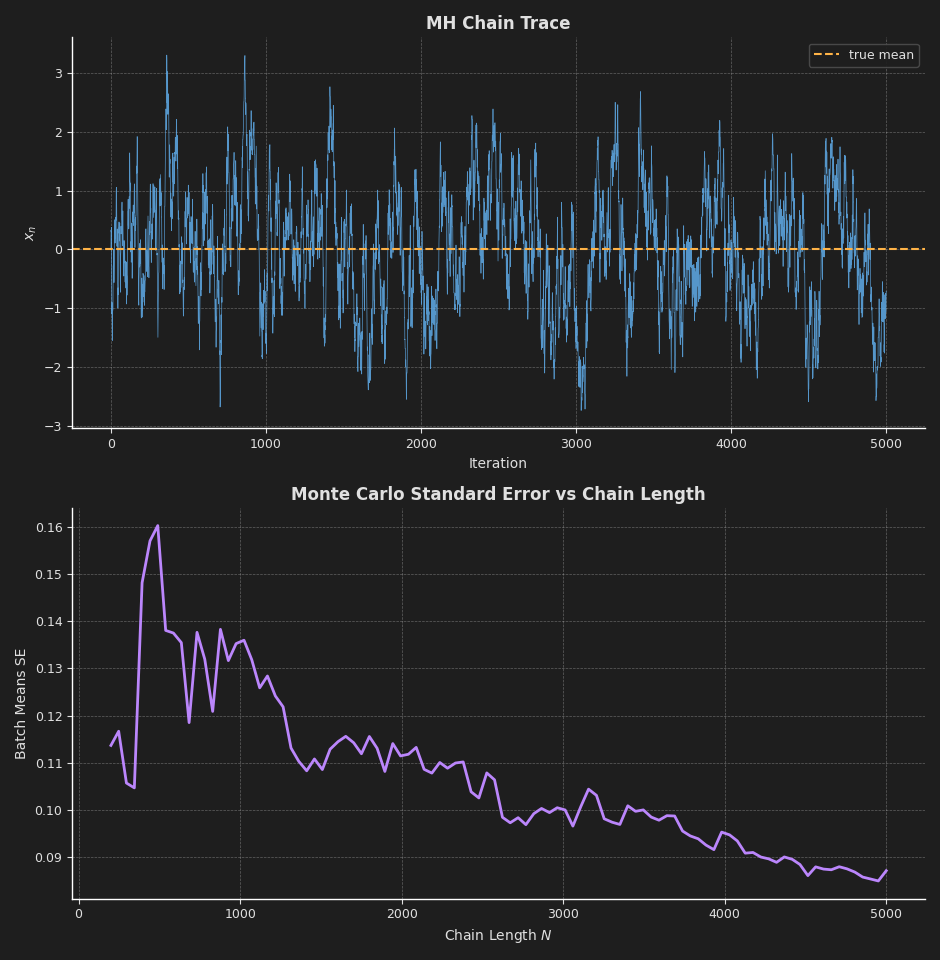

In [4]:
fig, axes = plt.subplots(2, 1, figsize=FIGSIZE_2PANEL)

# Left: trace plot
ax = axes[0]
ax.plot(np.arange(N), chain, color=C['blue'], lw=0.5, alpha=0.8)
ax.axhline(0, color=C['orange'], ls='--', lw=1.5, label='true mean')
ax.set_xlabel('Iteration')
ax.set_ylabel('$x_n$')
ax.set_title('MH Chain Trace')
ax.legend()

# Right: Monte Carlo SE shrinking with chain length
ax = axes[1]
ax.plot(ns, ses, color=C['purple'], lw=2)
ax.set_xlabel('Chain Length $N$')
ax.set_ylabel('Batch Means SE')
ax.set_title('Monte Carlo Standard Error vs Chain Length')
plt.tight_layout()

### Gelman-Rubin Statistic

An alternative to Monte Carlo standard errors is the Gelman-Rubin statistic $\hat{R}$, which compares between-chain and within-chain variance across multiple parallel chains. When the chains have converged, $\hat{R}$ should be close to 1.

In [5]:
def gelman_rubin(chains, D=None):
    """
    Compute the Gelman-Rubin R-hat statistic.
    chains : list of 1-D arrays of equal length
    D      : discard first D samples as burn-in (default: half)
    """
    J = len(chains)
    L = len(chains[0])
    if D is None:
        D = L // 2
    chains_trimmed = [c[D:] for c in chains]
    L_eff = len(chains_trimmed[0])

    chain_means = np.array([c.mean() for c in chains_trimmed])
    grand_mean = chain_means.mean()
    B = L_eff / (J - 1) * np.sum((chain_means - grand_mean)**2)
    within_vars = np.array([c.var(ddof=1) for c in chains_trimmed])
    W = within_vars.mean()

    R_hat = np.sqrt(((L_eff - 1) / L_eff * W + B / L_eff) / W)
    return R_hat

# Run 4 parallel chains with different starting values
starts = [-3, -1, 1, 3]
rng2 = np.random.default_rng(2024)

# Build R-hat over time as chains grow
n_steps = 5000
chains_full = []
for s in starts:
    chain_s = np.empty(n_steps)
    chain_s[0] = s
    for i in range(1, n_steps):
        prop = chain_s[i-1] + rng2.uniform(-0.5, 0.5)
        log_alpha = stats.norm.logpdf(prop) - stats.norm.logpdf(chain_s[i-1])
        if np.log(rng2.uniform()) <= log_alpha:
            chain_s[i] = prop
        else:
            chain_s[i] = chain_s[i-1]
    chains_full.append(chain_s)

# Compute R-hat at various chain lengths (need at least a few hundred samples)
ns_gr = np.arange(200, n_steps, 50)
r_hats = [gelman_rubin([c[:n] for c in chains_full]) for n in ns_gr]

print(f"Final R-hat ({n_steps} iterations): {r_hats[-1]:.4f}  (want < 1.1)")

Final R-hat (5000 iterations): 1.0252  (want < 1.1)


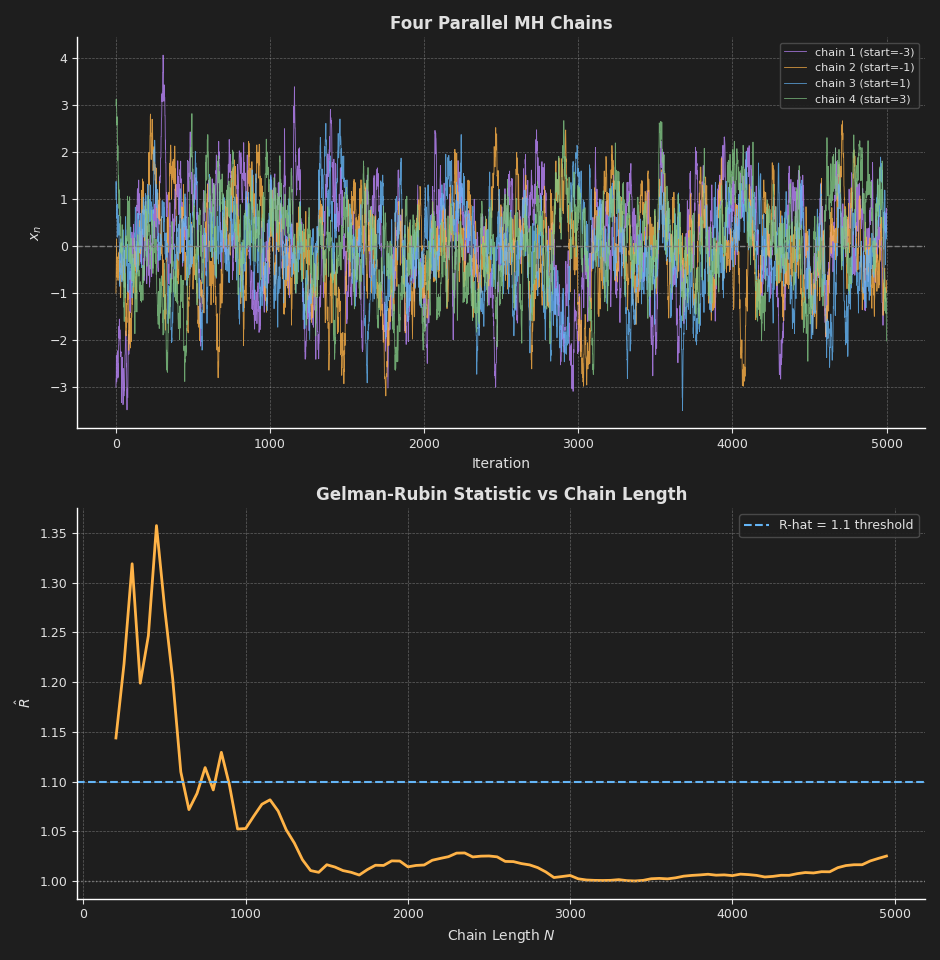

In [6]:
fig, axes = plt.subplots(2, 1, figsize=FIGSIZE_2PANEL)

# Left: 4 trace plots
ax = axes[0]
colors_list = [C['purple'], C['orange'], C['blue'], C.get('green', '#81C784')]
for j, (c, col) in enumerate(zip(chains_full, colors_list)):
    ax.plot(c, color=col, lw=0.6, alpha=0.8, label=f'chain {j+1} (start={starts[j]})')
ax.axhline(0, color='gray', ls='--', lw=1)
ax.set_xlabel('Iteration')
ax.set_ylabel('$x_n$')
ax.set_title('Four Parallel MH Chains')
ax.legend(fontsize=8)

# Right: R-hat convergence
ax = axes[1]
ax.plot(ns_gr, r_hats, color=C['orange'], lw=2)
ax.axhline(1.1, color=C['blue'], ls='--', lw=1.5, label='R-hat = 1.1 threshold')
ax.axhline(1.0, color='gray', ls=':', lw=1)
ax.set_xlabel('Chain Length $N$')
ax.set_ylabel(r'$\hat{R}$')
ax.set_title('Gelman-Rubin Statistic vs Chain Length')
ax.legend()
plt.tight_layout()